---
## Section 1: Why Personalized News Recommendation?

### The Key Idea

Online news platforms show thousands of articles every day. A general popularity-based feed cannot fully match each user's interests because different users read different topics, such as sports, finance, health, or politics.

This project builds a personalized news recommendation system using the MIND dataset. The goal is to rank candidate news articles so that articles a user is more likely to click appear higher in the recommendation list.

### Why Hybrid Recommendation?

A single recommendation signal is usually not enough:

- Content-based filtering understands what the article is about.
- Collaborative filtering uses behavior from similar users.
- Popularity captures trending news.
- Category and subcategory preference capture the user's topic interests.

The final model combines these signals using weighted hybrid scoring. This makes the system more stable than relying on only one method.


---
## Section 2: Dataset and Setup

### What We Use

The system uses the MINDsmall dataset, which contains news articles and user behavior logs.

| File | Purpose |
|---|---|
| news.tsv | News title, abstract, category, and subcategory |
| behaviors.tsv | User history, impressions, clicks, and non-clicks |

### Why These Data Matter

The news file provides the article content needed for NLP representation. The behavior file provides user reading history and impression-level click labels, which are needed for personalization and ranking evaluation.


In [1]:
import os
import re
import json
import pickle
import numpy as np
import pandas as pd

BASE_DIR  = r"C:\Users\Administrator\OneDrive\Desktop\WID3002 DataSet"
TRAIN_DIR = os.path.join(BASE_DIR, "MINDsmall_train")
DEV_DIR   = os.path.join(BASE_DIR, "MINDsmall_dev")

NEWS_COLS = [
    "news_id", "category", "subcategory", "title", "abstract",
    "url", "title_entities", "abstract_entities"
]

BEHAVIOR_COLS = [
    "impression_id", "user_id", "timestamp", "history", "impressions"
]

TOP_K = 10
ALPHA = 0.6
RANDOM_STATE = 42


---
## Section 3: Data Preprocessing

### What This Step Does

This section cleans the news data and converts the user behavior logs into a structured interaction table.

The original MIND impression format stores multiple candidate articles in one string, for example:

```
N123-1 N456-0 N789-0
```

This is expanded into separate rows so the model can analyze clicked and non-clicked articles more easily.

### Why This Is Needed

Recommendation models need consistent article IDs, clean text fields, and structured user-item interactions. Without this step, later NLP processing, user profiling, and evaluation would not be reliable.


In [2]:
def load_news(folder):
    return pd.read_csv(
        os.path.join(folder, "news.tsv"),
        sep="\t", header=None, names=NEWS_COLS
    )

news_raw = pd.concat([
    load_news(TRAIN_DIR),
    load_news(DEV_DIR)
], ignore_index=True).drop_duplicates(subset="news_id")

articles = news_raw[["news_id", "category", "subcategory", "title", "abstract"]].copy()
articles.dropna(subset=["title", "abstract"], inplace=True)
articles = articles[articles["title"].str.strip() != ""]
articles = articles[articles["abstract"].str.strip() != ""]
articles["category"] = articles["category"].str.strip().str.lower()
articles["subcategory"] = articles["subcategory"].fillna("").str.strip().str.lower()
articles.reset_index(drop=True, inplace=True)

print(f"Articles after cleaning: {len(articles)}")
articles.head()


Articles after cleaning: 61823


,news_id,category,subcategory,title,abstract
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the..."
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...
3,N53526,health,voices,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi..."
4,N38324,health,medical,"How to Get Rid of Skin Tags, According to a De...","They seem harmless, but there's a very good re..."


In [3]:
def load_behaviors(folder, split):
    df = pd.read_csv(
        os.path.join(folder, "behaviors.tsv"),
        sep="\t", header=None, names=BEHAVIOR_COLS
    )
    df["split"] = split
    return df

behaviors = pd.concat([
    load_behaviors(TRAIN_DIR, "train"),
    load_behaviors(DEV_DIR, "dev")
], ignore_index=True)

rows = []
for _, row in behaviors.iterrows():
    if pd.isna(row["impressions"]):
        continue
    for item in str(row["impressions"]).split():
        if "-" not in item:
            continue
        news_id, clicked = item.rsplit("-", 1)
        rows.append({
            "impression_id": row["impression_id"],
            "user_id": row["user_id"],
            "news_id": news_id,
            "clicked": int(clicked),
            "timestamp": row["timestamp"],
            "split": row["split"]
        })

interactions = pd.DataFrame(rows)
print(f"Interaction records: {len(interactions)}")
interactions.head()


Interaction records: 8584442


,impression_id,user_id,news_id,clicked,timestamp,split
0,1,U13740,N55689,1,11/11/2019 9:05:58 AM,train
1,1,U13740,N35729,0,11/11/2019 9:05:58 AM,train
2,2,U91836,N20678,0,11/12/2019 6:11:30 PM,train
3,2,U91836,N39317,0,11/12/2019 6:11:30 PM,train
4,2,U91836,N58114,0,11/12/2019 6:11:30 PM,train


In [4]:
articles.to_csv(os.path.join(BASE_DIR, "articles.csv"), index=False)
interactions.to_csv(os.path.join(BASE_DIR, "interactions.csv"), index=False)

print("========== DATA QUALITY REPORT ==========")
print(f"Articles:     {len(articles)}")
print(f"Interactions: {len(interactions)}")
print(f"Clicks:       {interactions['clicked'].sum()}")
print(f"Users:        {interactions['user_id'].nunique()}")
print("\nCategory distribution:")
print(articles["category"].value_counts().to_string())


========== DATA QUALITY REPORT ==========
Articles:     61823
Interactions: 8584442
Clicks:       347727
Users:        94057

Category distribution:
category
news             19305
sports           17750
finance           3718
foodanddrink      3072
travel            2843
lifestyle         2795
video             2709
weather           2379
health            2136
autos             1887
tv                1004
music              873
movies             668
entertainment      659
kids                21
middleeast           2
northamerica         1
games                1


---
## Section 4: NLP Article Representation

### What We Use

Each article is represented using its title and abstract. The text is cleaned, tokenized, lemmatized, and converted into numerical features.

| Method | Purpose |
|---|---|
| TF-IDF | Captures important keywords and phrases |
| SentenceTransformer | Captures semantic meaning of the article |

### Why Not Keywords Only?

TF-IDF is useful for exact word and phrase matching, but it may miss articles with similar meanings but different wording. Sentence embeddings help solve this by placing semantically related articles closer together in vector space.

Using both methods gives the system a stronger understanding of news content.


In [5]:
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer

nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])


c:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
def clean_text(text):
    text = re.sub(r"<[^>]+>", " ", str(text))
    text = re.sub(r"[^A-Za-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip().lower()


def tokenize(text):
    doc = nlp(text)
    return " ".join([
        token.lemma_
        for token in doc
        if not token.is_stop and not token.is_punct and len(token.text) > 1
    ])

articles["text"] = articles["title"] + " " + articles["abstract"]
articles["text_clean"] = articles["text"].apply(clean_text)
articles["text_tokens"] = articles["text_clean"].apply(tokenize)

articles[["news_id", "title", "text_tokens"]].head()


,news_id,title,text_tokens
0,N55528,"The Brands Queen Elizabeth, Prince Charles, an...",brands queen elizabeth prince charles prince p...
1,N19639,50 Worst Habits For Belly Fat,50 bad habit belly fat seemingly harmless habi...
2,N61837,The Cost of Trump's Aid Freeze in the Trenches...,cost trump aid freeze trench ukraine war lt iv...
3,N53526,I Was An NBA Wife. Here's How It Affected My M...,nba wife affect mental health feel like fraud ...
4,N38324,"How to Get Rid of Skin Tags, According to a De...",rid skin tag accord dermatologist harmless goo...


In [7]:
tfidf_vectorizer = TfidfVectorizer(max_features=30000, ngram_range=(1, 2))
tfidf_matrix = tfidf_vectorizer.fit_transform(articles["text_tokens"])

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")


TF-IDF matrix shape: (61823, 30000)


In [8]:
embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
article_embeddings = embedder.encode(
    articles["text_clean"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

article_id_index = {row["news_id"]: i for i, row in articles.iterrows()}
print(f"Embeddings shape: {article_embeddings.shape}")


Batches: 100%|██████████| 966/966 [03:39<00:00,  4.39it/s]


Embeddings shape: (61823, 384)


In [9]:
with open(os.path.join(BASE_DIR, "tfidf_vectorizer.pkl"), "wb") as f:
    pickle.dump(tfidf_vectorizer, f)
with open(os.path.join(BASE_DIR, "tfidf_matrix.pkl"), "wb") as f:
    pickle.dump(tfidf_matrix, f)
np.save(os.path.join(BASE_DIR, "article_embeddings.npy"), article_embeddings)
with open(os.path.join(BASE_DIR, "article_id_index.json"), "w") as f:
    json.dump(article_id_index, f)


---
## Section 5: User Profile and Recommendation Signals

### User Profile

A user profile is built from the user's previously clicked articles. The model uses recent reading history because recent clicks usually reflect the user's current interests better than older clicks.

Each user profile is calculated from article embeddings, with higher weight given to more recent articles.

### Recommendation Signals

The final ranking uses five signals:

| Signal | Why It Matters |
|---|---|
| content_score | Measures semantic similarity between user interest and candidate article |
| cf_score | Uses similar users' reading behavior |
| popularity_score | Captures generally popular or trending news |
| category_score | Matches broad user topic preference |
| subcategory_score | Matches more specific user topic preference |

### Why Add Subcategory?

Category is useful but broad. For example, a user may like sports, but specifically NBA or NFL. Subcategory preference gives a finer signal and helps the model rank more relevant articles.


In [10]:
def extract_history_clicks(behavior_df):
    rows = []
    for _, row in behavior_df.iterrows():
        if pd.isna(row["history"]):
            continue
        for pos, news_id in enumerate(str(row["history"]).split()):
            if news_id in article_id_index:
                rows.append({
                    "user_id": row["user_id"],
                    "news_id": news_id,
                    "timestamp": row["timestamp"],
                    "position": pos
                })
    return pd.DataFrame(rows)

train_behaviors = behaviors[behaviors["split"] == "train"].copy()
train_clicked = interactions[
    (interactions["split"] == "train") & (interactions["clicked"] == 1)
][["user_id", "news_id", "timestamp"]].copy()

history_clicks = extract_history_clicks(train_behaviors)
profile_events = pd.concat([
    train_clicked,
    history_clicks[["user_id", "news_id", "timestamp"]]
], ignore_index=True)

profile_events = profile_events[profile_events["news_id"].isin(article_id_index)]
profile_events["timestamp"] = pd.to_datetime(profile_events["timestamp"])
profile_events = profile_events.sort_values(["user_id", "timestamp"])

print(f"Profile events: {len(profile_events)} | Users: {profile_events['user_id'].nunique()}")


Profile events: 5177195 | Users: 49989


In [11]:
article_category = articles.set_index("news_id")["category"].to_dict()
article_subcategory = articles.set_index("news_id")["subcategory"].to_dict()

user_profiles = {}
user_category_preferences = {}
user_subcategory_preferences = {}

for user_id, group in profile_events.groupby("user_id"):
    group = group.tail(50)
    indices = [article_id_index[nid] for nid in group["news_id"]]
    embs = article_embeddings[indices]

    n = len(embs)
    weights = np.exp(np.linspace(-1.5, 0, n)).astype(np.float32)
    weights = weights / weights.sum()
    profile = np.average(embs, axis=0, weights=weights)
    profile = profile / (np.linalg.norm(profile) + 1e-9)
    user_profiles[user_id] = profile

    cats = [article_category.get(nid) for nid in group["news_id"]]
    cats = [cat for cat in cats if pd.notna(cat)]
    user_category_preferences[user_id] = pd.Series(cats).value_counts(normalize=True).to_dict()

    subcats = [article_subcategory.get(nid) for nid in group["news_id"]]
    subcats = [subcat for subcat in subcats if pd.notna(subcat) and subcat != ""]
    user_subcategory_preferences[user_id] = pd.Series(subcats).value_counts(normalize=True).to_dict()

print(f"User profiles built: {len(user_profiles)}")


User profiles built: 49989


In [12]:
click_counts = train_clicked.groupby("news_id").size().reset_index(name="click_count")
click_counts = click_counts.merge(articles[["news_id", "category"]], on="news_id", how="left")
click_counts["click_count"] = click_counts["click_count"].fillna(0)

click_count_map = click_counts.set_index("news_id")["click_count"].to_dict()
max_click_count = max(click_count_map.values()) if len(click_count_map) else 1

popular_global = click_counts.sort_values("click_count", ascending=False)["news_id"].head(100).tolist()

popular_by_category = {}
for category, group in click_counts.groupby("category"):
    popular_by_category[category] = group.sort_values("click_count", ascending=False)["news_id"].head(50).tolist()

clicks_per_user = profile_events.groupby("user_id").size()
cold_start_users = set(clicks_per_user[clicks_per_user < 3].index)

print(f"Global popular articles: {len(popular_global)}")
print(f"Categories with popularity fallback: {len(popular_by_category)}")
print(f"Cold-start users: {len(cold_start_users)}")


Global popular articles: 100
Categories with popularity fallback: 16
Cold-start users: 464


---
## Section 6: Collaborative Filtering

### Why Collaborative Filtering?

Content similarity only looks at article meaning. Collaborative filtering adds behavior patterns from other users. If users with similar histories clicked a candidate article, that article may also be relevant to the current user.

### How It Works

A sparse user-article interaction matrix is built from historical clicks. Cosine similarity is then used to find users with similar reading histories. Their clicked articles provide the collaborative filtering score.


In [13]:
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

cf_events = profile_events.drop_duplicates(["user_id", "news_id"])
user_list = sorted(cf_events["user_id"].unique())
article_list = sorted(cf_events["news_id"].unique())

user_idx = {user_id: i for i, user_id in enumerate(user_list)}
article_idx = {news_id: i for i, news_id in enumerate(article_list)}

row_idx = cf_events["user_id"].map(user_idx).to_numpy()
col_idx = cf_events["news_id"].map(article_idx).to_numpy()
values = np.ones(len(cf_events), dtype=np.float32)

interaction_matrix = csr_matrix(
    (values, (row_idx, col_idx)),
    shape=(len(user_list), len(article_list))
)

print(f"Interaction matrix shape: {interaction_matrix.shape}")


Interaction matrix shape: (49989, 37925)


In [14]:
def collaborative_candidate_scores(user_id, candidate_news_ids, top_n_similar=50):
    if user_id not in user_idx:
        return np.zeros(len(candidate_news_ids), dtype=np.float32)

    uid = user_idx[user_id]
    user_vector = interaction_matrix[uid]

    similarities = cosine_similarity(user_vector, interaction_matrix).ravel()
    similarities[uid] = 0

    top_users = np.argsort(similarities)[::-1][:top_n_similar]
    top_weights = similarities[top_users]

    if top_weights.sum() <= 0:
        return np.zeros(len(candidate_news_ids), dtype=np.float32)

    neighbor_click_scores = interaction_matrix[top_users].T.dot(top_weights) / (top_weights.sum() + 1e-9)
    neighbor_click_scores = np.asarray(neighbor_click_scores).ravel()

    scores = []
    for news_id in candidate_news_ids:
        if news_id in article_idx:
            scores.append(neighbor_click_scores[article_idx[news_id]])
        else:
            scores.append(0.0)
    return np.asarray(scores, dtype=np.float32)


---
## Section 7: Hybrid Ranking Model

### Final Scoring Formula

The model ranks candidate articles using weighted scoring:

```
final_score =
    content_weight * content_score +
    cf_weight * cf_score +
    popularity_weight * popularity_score +
    category_weight * category_score +
    subcategory_weight * subcategory_score
```

### Why This Design?

Each signal captures a different part of recommendation quality. Content and subcategory preference personalize the recommendation, popularity keeps the system stable for trending news, and collaborative filtering adds behavior-based information.

The model uses candidate ranking, which matches the structure of the MIND dataset. Instead of selecting from the entire news collection, the model ranks the candidate articles shown in each impression.


In [15]:
def parse_impressions(impressions):
    candidates, labels = [], []
    if pd.isna(impressions):
        return candidates, labels

    for item in str(impressions).split():
        if "-" not in item:
            continue
        news_id, label = item.rsplit("-", 1)
        if news_id in article_id_index:
            candidates.append(news_id)
            labels.append(int(label))
    return candidates, labels


def normalize_scores(scores):
    scores = np.asarray(scores, dtype=np.float32)
    if len(scores) == 0:
        return scores
    return (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)


def build_profile_from_history(history, max_history=50):
    if pd.isna(history):
        return None

    news_ids = [nid for nid in str(history).split() if nid in article_id_index]
    if len(news_ids) == 0:
        return None

    news_ids = news_ids[-max_history:]
    indices = [article_id_index[nid] for nid in news_ids]
    embs = article_embeddings[indices]

    n = len(embs)
    weights = np.exp(np.linspace(-1.5, 0, n)).astype(np.float32)
    weights = weights / weights.sum()

    profile = np.average(embs, axis=0, weights=weights)
    profile = profile / (np.linalg.norm(profile) + 1e-9)
    return profile


def build_category_preference_from_history(history, max_history=50):
    if pd.isna(history):
        return {}

    news_ids = [nid for nid in str(history).split() if nid in article_category]
    news_ids = news_ids[-max_history:]
    categories = [article_category.get(nid) for nid in news_ids]
    categories = [cat for cat in categories if pd.notna(cat)]

    if len(categories) == 0:
        return {}
    return pd.Series(categories).value_counts(normalize=True).to_dict()


def build_subcategory_preference_from_history(history, max_history=50):
    if pd.isna(history):
        return {}

    news_ids = [nid for nid in str(history).split() if nid in article_subcategory]
    news_ids = news_ids[-max_history:]
    subcategories = [article_subcategory.get(nid) for nid in news_ids]
    subcategories = [subcat for subcat in subcategories if pd.notna(subcat) and subcat != ""]

    if len(subcategories) == 0:
        return {}
    return pd.Series(subcategories).value_counts(normalize=True).to_dict()


def content_candidate_scores(user_id, candidate_news_ids, history=None):
    profile = user_profiles.get(user_id)
    if profile is None:
        profile = build_profile_from_history(history)

    if profile is None:
        return np.zeros(len(candidate_news_ids), dtype=np.float32)

    candidate_indices = [article_id_index[nid] for nid in candidate_news_ids]
    candidate_embeddings = article_embeddings[candidate_indices]
    return candidate_embeddings.dot(profile)


def popularity_candidate_scores(candidate_news_ids):
    return np.asarray([
        click_count_map.get(nid, 0) / (max_click_count + 1e-9)
        for nid in candidate_news_ids
    ], dtype=np.float32)


def category_candidate_scores(user_id, candidate_news_ids, history=None):
    category_pref = user_category_preferences.get(user_id)
    if not category_pref:
        category_pref = build_category_preference_from_history(history)

    return np.asarray([
        category_pref.get(article_category.get(nid), 0.0)
        for nid in candidate_news_ids
    ], dtype=np.float32)


def subcategory_candidate_scores(user_id, candidate_news_ids, history=None):
    subcategory_pref = user_subcategory_preferences.get(user_id)
    if not subcategory_pref:
        subcategory_pref = build_subcategory_preference_from_history(history)

    return np.asarray([
        subcategory_pref.get(article_subcategory.get(nid), 0.0)
        for nid in candidate_news_ids
    ], dtype=np.float32)


DEFAULT_WEIGHTS = {
    "content": 0.50,
    "cf": 0.10,
    "popularity": 0.20,
    "category": 0.10,
    "subcategory": 0.10,
}


def hybrid_rank_candidates(user_id, candidate_news_ids, history=None, weights=None):
    if len(candidate_news_ids) == 0:
        return pd.DataFrame()

    if weights is None:
        weights = DEFAULT_WEIGHTS

    content_scores = normalize_scores(content_candidate_scores(user_id, candidate_news_ids, history))
    cf_scores = normalize_scores(collaborative_candidate_scores(user_id, candidate_news_ids))
    popularity_scores = normalize_scores(popularity_candidate_scores(candidate_news_ids))
    category_scores = normalize_scores(category_candidate_scores(user_id, candidate_news_ids, history))
    subcategory_scores = normalize_scores(subcategory_candidate_scores(user_id, candidate_news_ids, history))

    final_scores = (
        weights["content"] * content_scores +
        weights["cf"] * cf_scores +
        weights["popularity"] * popularity_scores +
        weights["category"] * category_scores +
        weights["subcategory"] * subcategory_scores
    )

    if content_scores.sum() == 0 and cf_scores.sum() == 0 and category_scores.sum() == 0 and subcategory_scores.sum() == 0:
        final_scores = popularity_scores

    ranked = pd.DataFrame({
        "news_id": candidate_news_ids,
        "score": final_scores,
        "content_score": content_scores,
        "cf_score": cf_scores,
        "popularity_score": popularity_scores,
        "category_score": category_scores,
        "subcategory_score": subcategory_scores
    }).sort_values("score", ascending=False)

    return ranked


In [16]:
sample_dev = behaviors[behaviors["split"] == "dev"].iloc[0]
sample_candidates, sample_labels = parse_impressions(sample_dev["impressions"])

sample_ranking = hybrid_rank_candidates(
    sample_dev["user_id"],
    sample_candidates,
    history=sample_dev["history"]
)
print(f"Sample user: {sample_dev['user_id']}")
sample_ranking.head(10)


Sample user: U80234


,news_id,score,content_score,cf_score,popularity_score,category_score,subcategory_score
14,N42844,0.646667,1.000000,0.0,0.000000,0.8,0.666667
3,N34130,0.611988,0.930642,0.0,0.000000,0.8,0.666667
4,N6916,0.597810,0.755621,0.0,1.000000,0.2,0.000000
15,N49285,0.569202,0.845070,0.0,0.000000,0.8,0.666667
9,N33176,0.480588,0.561177,0.0,0.000000,1.0,1.000000
7,N24802,0.465275,0.530550,0.0,0.000000,1.0,1.000000
17,N53572,0.454686,0.909372,0.0,0.000000,0.0,0.000000
11,N5940,0.408888,0.683837,0.0,0.068182,0.2,0.333333
20,N55237,0.371307,0.702613,0.0,0.000000,0.2,0.000000
18,N11930,0.357205,0.619865,0.0,0.136364,0.2,0.000000


---
## Section 8: Evaluation Metrics

### What We Measure

The model is evaluated using ranking metrics.

| Metric | Meaning |
|---|---|
| Precision@K | How many top-K recommendations are clicked |
| Recall@K | How many clicked articles are retrieved in top-K |
| NDCG@K | Whether clicked articles appear near the top |

NDCG@10 is the main metric because ranking position matters in news recommendation.


In [17]:
def precision_at_k(labels, k):
    labels = labels[:k]
    return np.sum(labels) / k


def recall_at_k(labels, k):
    total_relevant = np.sum(labels)
    if total_relevant == 0:
        return 0.0
    return np.sum(labels[:k]) / total_relevant


def ndcg_at_k(labels, k):
    labels = np.asarray(labels[:k], dtype=np.float32)
    dcg = np.sum(labels / np.log2(np.arange(2, len(labels) + 2)))
    ideal = np.sort(labels)[::-1]
    idcg = np.sum(ideal / np.log2(np.arange(2, len(ideal) + 2)))
    return dcg / idcg if idcg > 0 else 0.0


---
## Section 9: Weight Tuning

### Why Tune Weights?

The five recommendation signals do not contribute equally. Weight tuning tests several combinations and selects the one with the best NDCG@10 on a validation subset.

This does not prove a globally optimal solution, but it gives a practical empirical setting for the hybrid model.


In [18]:
def score_weights(behavior_df, weights, max_impressions=3000):
    scores = []
    checked = 0

    for _, row in behavior_df.iterrows():
        candidates, labels = parse_impressions(row["impressions"])
        if len(candidates) < 2 or sum(labels) == 0:
            continue

        ranked = hybrid_rank_candidates(
            row["user_id"],
            candidates,
            history=row["history"],
            weights=weights
        )
        label_map = dict(zip(candidates, labels))
        ranked_labels = [label_map[nid] for nid in ranked["news_id"]]
        scores.append(ndcg_at_k(ranked_labels, 10))

        checked += 1
        if checked >= max_impressions:
            break

    return float(np.mean(scores))


weight_candidates = [
    {"content": 0.50, "cf": 0.10, "popularity": 0.20, "category": 0.10, "subcategory": 0.10},
    {"content": 0.45, "cf": 0.10, "popularity": 0.20, "category": 0.10, "subcategory": 0.15},
    {"content": 0.45, "cf": 0.10, "popularity": 0.25, "category": 0.10, "subcategory": 0.10},
    {"content": 0.55, "cf": 0.05, "popularity": 0.20, "category": 0.10, "subcategory": 0.10},
    {"content": 0.40, "cf": 0.10, "popularity": 0.25, "category": 0.10, "subcategory": 0.15},
]

tuning_behaviors = behaviors[behaviors["split"] == "dev"].copy()

tuning_results = []
for weights in weight_candidates:
    ndcg10 = score_weights(tuning_behaviors, weights, max_impressions=3000)
    tuning_results.append({**weights, "NDCG@10": ndcg10})

tuning_results = pd.DataFrame(tuning_results).sort_values("NDCG@10", ascending=False)
BEST_WEIGHTS = tuning_results.iloc[0][["content", "cf", "popularity", "category", "subcategory"]].to_dict()

tuning_results


,content,cf,popularity,category,subcategory,NDCG@10
1,0.45,0.10,0.20,0.1,0.15,0.440948
0,0.50,0.10,0.20,0.1,0.10,0.436730
3,0.55,0.05,0.20,0.1,0.10,0.436016
4,0.40,0.10,0.25,0.1,0.15,0.436001
2,0.45,0.10,0.25,0.1,0.10,0.435593


---
## Section 10: Generate Recommendations

The selected weights are used to rank candidate articles for all validation impressions. The output table stores the final rank, click label, and each component score for analysis.


In [19]:
dev_behaviors = behaviors[behaviors["split"] == "dev"].copy()

ranked_rows = []
for _, row in dev_behaviors.iterrows():
    candidates, labels = parse_impressions(row["impressions"])
    if not candidates:
        continue

    ranked = hybrid_rank_candidates(
        row["user_id"],
        candidates,
        history=row["history"],
        weights=BEST_WEIGHTS
    )
    label_map = dict(zip(candidates, labels))

    for rank, (_, rec) in enumerate(ranked.iterrows(), 1):
        ranked_rows.append({
            "impression_id": row["impression_id"],
            "user_id": row["user_id"],
            "news_id": rec["news_id"],
            "rank": rank,
            "label": label_map.get(rec["news_id"], 0),
            "score": rec["score"],
            "content_score": rec["content_score"],
            "cf_score": rec["cf_score"],
            "popularity_score": rec["popularity_score"],
            "category_score": rec["category_score"],
            "subcategory_score": rec["subcategory_score"]
        })

ranked_recommendations = pd.DataFrame(ranked_rows)
ranked_recommendations.to_csv(os.path.join(BASE_DIR, "ranked_recommendations.csv"), index=False)
ranked_recommendations.head()


,impression_id,user_id,news_id,rank,label,score,content_score,cf_score,popularity_score,category_score,subcategory_score
0,1,U80234,N42844,1,0,0.630000,1.000000,0.0,0.0,0.8,0.666667
1,1,U80234,N34130,2,0,0.598789,0.930642,0.0,0.0,0.8,0.666667
2,1,U80234,N49285,3,0,0.560282,0.845070,0.0,0.0,0.8,0.666667
3,1,U80234,N6916,4,0,0.560029,0.755621,0.0,1.0,0.2,0.000000
4,1,U80234,N33176,5,0,0.502530,0.561177,0.0,0.0,1.0,1.000000


---
## Section 11: Model Evaluation

The hybrid model is evaluated on the validation impressions using Precision@5, Recall@5, NDCG@5, Precision@10, Recall@10, and NDCG@10.


In [20]:
def evaluate_ranked_dataframe(ranked_df):
    results = {"P@5": [], "R@5": [], "NDCG@5": [], "P@10": [], "R@10": [], "NDCG@10": []}

    for _, group in ranked_df.groupby("impression_id"):
        labels = group.sort_values("rank")["label"].to_numpy()
        if labels.sum() == 0:
            continue
        results["P@5"].append(precision_at_k(labels, 5))
        results["R@5"].append(recall_at_k(labels, 5))
        results["NDCG@5"].append(ndcg_at_k(labels, 5))
        results["P@10"].append(precision_at_k(labels, 10))
        results["R@10"].append(recall_at_k(labels, 10))
        results["NDCG@10"].append(ndcg_at_k(labels, 10))

    return {metric: float(np.mean(values)) for metric, values in results.items()}


hybrid_scores = evaluate_ranked_dataframe(ranked_recommendations)
print("Hybrid CF + Content-Based Model:")
for metric, value in hybrid_scores.items():
    print(f"  {metric}: {value:.4f}")


Hybrid CF + Content-Based Model:
  P@5: 0.1209
  R@5: 0.4795
  NDCG@5: 0.3825
  P@10: 0.0849
  R@10: 0.6466
  NDCG@10: 0.4359


---
## Section 12: Popularity Baseline

### Why Baseline?

A popularity baseline ranks articles only by training click count. This is a simple but strong baseline because popular news often attracts many users.

The hybrid model should outperform this baseline to show that personalization adds value beyond recommending generally popular articles.


In [21]:
baseline_rows = []
for _, row in dev_behaviors.iterrows():
    candidates, labels = parse_impressions(row["impressions"])
    if not candidates:
        continue

    baseline = pd.DataFrame({
        "news_id": candidates,
        "label": labels,
        "score": [click_count_map.get(nid, 0) for nid in candidates]
    }).sort_values("score", ascending=False)

    for rank, (_, rec) in enumerate(baseline.iterrows(), 1):
        baseline_rows.append({
            "impression_id": row["impression_id"],
            "user_id": row["user_id"],
            "news_id": rec["news_id"],
            "rank": rank,
            "label": rec["label"],
            "score": rec["score"]
        })

baseline_ranked = pd.DataFrame(baseline_rows)
baseline_scores = evaluate_ranked_dataframe(baseline_ranked)

print("Popularity Baseline:")
for metric, value in baseline_scores.items():
    print(f"  {metric}: {value:.4f}")


Popularity Baseline:
  P@5: 0.0906
  R@5: 0.3782
  NDCG@5: 0.2784
  P@10: 0.0688
  R@10: 0.5489
  NDCG@10: 0.3375


---
## Section 13: Final Comparison

The table compares the hybrid model with the popularity baseline and shows the improvement for each metric.


In [22]:
comparison = pd.DataFrame({
    "Metric": list(hybrid_scores.keys()),
    "Hybrid Model": [round(v, 4) for v in hybrid_scores.values()],
    "Popularity Baseline": [round(baseline_scores[m], 4) for m in hybrid_scores.keys()]
})
comparison["Improvement"] = (comparison["Hybrid Model"] - comparison["Popularity Baseline"]).round(4)

comparison.to_csv(os.path.join(BASE_DIR, "metrics_comparison.csv"), index=False)
print(comparison.to_string(index=False))


 Metric  Hybrid Model  Popularity Baseline  Improvement
    P@5        0.1209               0.0906       0.0303
    R@5        0.4795               0.3782       0.1013
 NDCG@5        0.3825               0.2784       0.1041
   P@10        0.0849               0.0688       0.0161
   R@10        0.6466               0.5489       0.0977
NDCG@10        0.4359               0.3375       0.0984


---
## Section 14: Visualization and Conclusion

The bar chart summarizes the performance difference between the hybrid model and the popularity baseline.

The final system combines semantic article understanding, user reading history, collaborative filtering, popularity, category preference, and subcategory preference. The evaluation shows whether the personalized hybrid model provides stronger ranking quality than a non-personalized method.


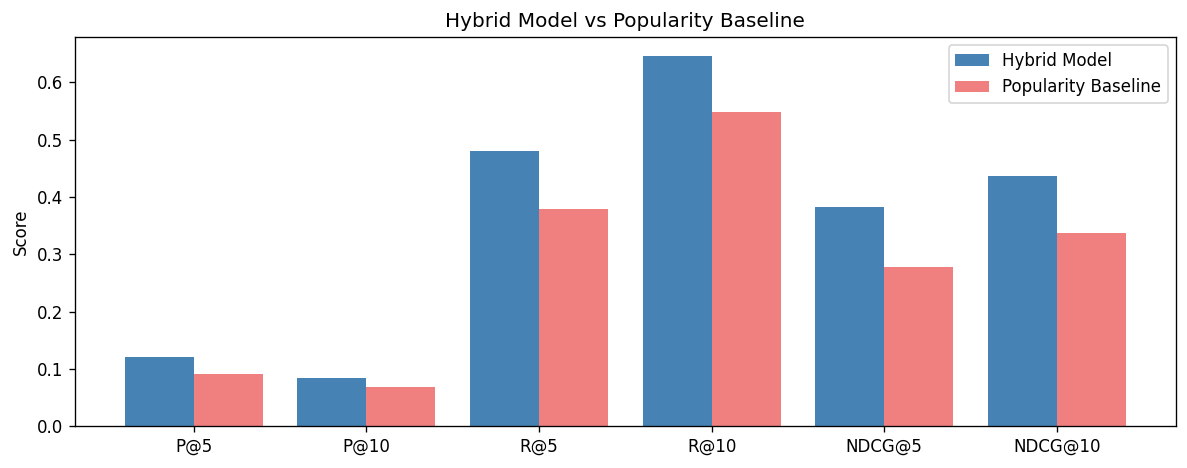

In [23]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

metrics = ["P@5", "P@10", "R@5", "R@10", "NDCG@5", "NDCG@10"]
hybrid_values = [hybrid_scores[m] for m in metrics]
baseline_values = [baseline_scores[m] for m in metrics]
x = np.arange(len(metrics))

plt.figure(figsize=(10, 4))
plt.bar(x - 0.2, hybrid_values, width=0.4, label="Hybrid Model", color="steelblue")
plt.bar(x + 0.2, baseline_values, width=0.4, label="Popularity Baseline", color="lightcoral")
plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Hybrid Model vs Popularity Baseline")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "evaluation_plot.png"), dpi=150)
plt.show()
